## Flow GW



In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import matplotlib.pyplot as plt
import torch
import pandas as pd

from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from scipy.spatial.distance import cdist, pdist, squareform
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


from colors import color_segment
from supervised_vae import SupervisedVAE
from train_two_vaes import train_two_vaes
from plot_vaes import plot_vae_latent_alignment
from utils_GW import *
from geodesics import *

blue_pink = color_segment()

In [2]:
# --- config ---
latent_dim = 8
num_classes = 3
prefix = "checkpoints/mnist_same_3classes"  # must match training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- load models ---
vaeA = SupervisedVAE(latent_dim=latent_dim, num_classes=num_classes)
vaeB = SupervisedVAE(latent_dim=latent_dim, num_classes=num_classes)

vaeA.load_state_dict(torch.load(f"{prefix}_vaeA.pt", map_location=device))
vaeB.load_state_dict(torch.load(f"{prefix}_vaeB.pt", map_location=device))

vaeA.to(device).eval()
vaeB.to(device).eval()

# --- load data splits (need align + test) ---
A_align = torch.load(f"{prefix}_A_align.pt", map_location="cpu")
B_align = torch.load(f"{prefix}_B_align.pt", map_location="cpu")

A_test = torch.load(f"{prefix}_A_test.pt", map_location="cpu")
B_test = torch.load(f"{prefix}_B_test.pt", map_location="cpu")

# --- extract latents (with labels) ---
zA_align = A_align["z"]
zB_align = B_align["z"]
y_align  = A_align["y"]

zA_test = A_test["z"]
zB_test = B_test["z"]
y_test  = A_test["y"]

#### LDD 

#### Flow GW

In [3]:
# ============================================================
# Algorithm 1 without LDD
# Reference domain: A
# Input domain: B
# Learned map: B -> A
# ============================================================

# ------------------------------------------------------------
# 0) Small helpers
# ------------------------------------------------------------

def as_torch_float(x, device=device):
    if torch.is_tensor(x):
        return x.to(device=device, dtype=torch.float32)
    return torch.tensor(np.asarray(x), dtype=torch.float32, device=device)

def as_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


# ------------------------------------------------------------
# 1) Decoder feature map for metric tensor computation
# ------------------------------------------------------------

def decoder_feature_map(model, z, output_space="logits"):
    """
    Map latent point(s) z to flattened decoder outputs.

    output_space:
        - "logits": use decoder logits directly
        - "probs":  use sigmoid(decoder logits)

    Returns
    -------
    feat : (B, D_obs) tensor
    """
    logits = model.decode(z)
    feat = logits.view(logits.shape[0], -1)

    if output_space == "logits":
        return feat
    elif output_space == "probs":
        return torch.sigmoid(feat)
    else:
        raise ValueError("output_space must be 'logits' or 'probs'")


# ------------------------------------------------------------
# 2) Geodesic distance matrices
#    Uses the same line-energy approximation idea as your setup
# ------------------------------------------------------------

def pairwise_geodesic_distance_matrix(
    model,
    latent_points,
    num_segments=10,
    device=device,
    detach=True,
):
    """
    Pairwise geodesic distance matrix using linear_path_energy.

    Parameters
    ----------
    model : VAE model
    latent_points : (N, d)
    num_segments : int
    detach : bool
        If True, computes without gradients.
        For Phase 1 we want detach=True.

    Returns
    -------
    D : (N, N) tensor
    """
    Z = as_torch_float(latent_points, device=device)
    n = Z.shape[0]
    D = torch.zeros(n, n, dtype=Z.dtype, device=device)

    was_training = model.training
    model.eval()

    ctx = torch.no_grad() if detach else torch.enable_grad()
    with ctx:
        for i in range(n):
            for j in range(i + 1, n):
                _, d_ij = linear_path_energy(
                    model,
                    Z[i],
                    Z[j],
                    num_segments=num_segments,
                    device=device,
                )
                D[i, j] = d_ij
                D[j, i] = d_ij

    if was_training:
        model.train()

    return D


def compute_anchor_geodesic_matrices(
    zA_anchor,
    zB_anchor,
    vaeA,
    vaeB,
    num_segments=10,
    device=device,
    verbose=True,
):
    """
    Phase 1:
    Compute geodesic distance matrices on anchor split.

    Returns
    -------
    C_A : (N, N) numpy
    C_B : (N, N) numpy
    """
    if verbose:
        print("[Phase 1] Computing anchor geodesic matrix in A...")
    C_A = pairwise_geodesic_distance_matrix(
        vaeA,
        zA_anchor,
        num_segments=num_segments,
        device=device,
        detach=True,
    ).cpu().numpy()

    if verbose:
        print("[Phase 1] Computing anchor geodesic matrix in B...")
    C_B = pairwise_geodesic_distance_matrix(
        vaeB,
        zB_anchor,
        num_segments=num_segments,
        device=device,
        detach=True,
    ).cpu().numpy()

    return C_A, C_B


# ------------------------------------------------------------
# 3) Pullback metric tensors in the target/reference domain
#    G(z) = J(z)^T J(z)
# ------------------------------------------------------------

def pullback_metric_tensor_single(
    model,
    z_single,
    output_space="logits",
):
    """
    Compute pullback metric tensor G(z) = J^T J for one latent point z.

    z_single : (d,) tensor on correct device
    Returns  : (d, d) tensor
    """
    z_single = z_single.detach().clone().requires_grad_(True)

    def f(z_vec):
        out = decoder_feature_map(model, z_vec.unsqueeze(0), output_space=output_space)
        return out.squeeze(0)   # (D_obs,)

    J = torch.autograd.functional.jacobian(f, z_single, create_graph=False)  # (D_obs, d)
    G = J.transpose(0, 1) @ J
    return G


def compute_pullback_metric_tensors(
    model,
    latent_points,
    output_space="logits",
    device=device,
    verbose=True,
):
    """
    Compute pullback metric tensors G_i in the reference domain.

    Parameters
    ----------
    model : VAE model
    latent_points : (N, d)
    output_space : "logits" or "probs"

    Returns
    -------
    G : (N, d, d) tensor on device
    """
    Z = as_torch_float(latent_points, device=device)
    n = Z.shape[0]
    d = Z.shape[1]

    G_all = torch.zeros(n, d, d, dtype=Z.dtype, device=device)

    was_training = model.training
    model.eval()

    for i in range(n):
        if verbose and ((i + 1) % 50 == 0 or i == 0 or i + 1 == n):
            print(f"[Phase 4 prep] Metric tensor {i+1}/{n}")
        G_all[i] = pullback_metric_tensor_single(
            model,
            Z[i],
            output_space=output_space,
        )

    if was_training:
        model.train()

    return G_all


# ------------------------------------------------------------
# 4) Phase 4 losses
# ------------------------------------------------------------

def coupling_weighted_metric_tensor_loss(
    X_ref,
    Y_pred,
    P,
    G_ref,
    chunk_size=None,
):
    """
    Algorithm 1 Phase 4 metric-tensor loss:

        L = sum_{i,j} P_ij (Y_pred_j - X_ref_i)^T G_ref_i (Y_pred_j - X_ref_i)

    where:
        X_ref : (N_ref, d) anchors in reference domain A
        Y_pred: (N_in, d) mapped anchors T(zB)
        P     : (N_ref, N_in) GW coupling
        G_ref : (N_ref, d, d) pullback metrics at X_ref

    chunk_size:
        use chunking over j for memory safety
    """
    N_ref, d = X_ref.shape
    N_in = Y_pred.shape[0]

    if chunk_size is None:
        chunk_size = N_in

    total = 0.0
    for j0 in range(0, N_in, chunk_size):
        j1 = min(j0 + chunk_size, N_in)

        Y_chunk = Y_pred[j0:j1]               # (B, d)
        P_chunk = P[:, j0:j1]                 # (N_ref, B)

        diff = Y_chunk.unsqueeze(0) - X_ref.unsqueeze(1)    # (N_ref, B, d)
        quad = torch.einsum("nbd,ndk,nbk->nb", diff, G_ref, diff)  # (N_ref, B)

        total = total + (P_chunk * quad).sum()

    return total


def coupling_weighted_euclidean_loss(
    X_ref,
    Y_pred,
    P,
    chunk_size=None,
):
    """
    Euclidean fallback:
        L = sum_{i,j} P_ij ||Y_pred_j - X_ref_i||^2
    """
    N_ref, d = X_ref.shape
    N_in = Y_pred.shape[0]

    if chunk_size is None:
        chunk_size = N_in

    total = 0.0
    for j0 in range(0, N_in, chunk_size):
        j1 = min(j0 + chunk_size, N_in)

        Y_chunk = Y_pred[j0:j1]
        P_chunk = P[:, j0:j1]

        diff = Y_chunk.unsqueeze(0) - X_ref.unsqueeze(1)
        sq = (diff ** 2).sum(dim=2)

        total = total + (P_chunk * sq).sum()

    return total


# ------------------------------------------------------------
# 5) Phase 4 training: fit continuous map from GW coupling
# ------------------------------------------------------------

def train_flow_phase4_from_gw(
    z_ref_anchor,            # A anchors
    z_in_anchor,             # B anchors
    P_star,                  # shape (N_A, N_B)
    G_ref=None,              # shape (N_A, d, d), optional
    loss_type="metric_tensor",   # "metric_tensor" or "euclidean"
    transforms=4,
    hidden_features=(64, 64),
    bins=8,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=1000,
    patience=200,
    min_delta=1e-4,
    restore_best=True,
    chunk_size=None,
    device=device,
    verbose=True,
):
    """
    Phase 4:
    Fit continuous map T : B -> A using GW coupling P_star.

    If loss_type == "metric_tensor", G_ref must be provided.
    """
    X_ref = as_torch_float(z_ref_anchor, device=device)   # A
    X_in = as_torch_float(z_in_anchor, device=device)     # B
    P_t = as_torch_float(P_star, device=device)

    if loss_type == "metric_tensor":
        if G_ref is None:
            raise ValueError("G_ref must be provided when loss_type='metric_tensor'")
        G_ref_t = G_ref.to(device=device, dtype=torch.float32)
    else:
        G_ref_t = None

    model = ZukoFlowMap(
        latent_dim=X_in.shape[1],
        transforms=transforms,
        hidden_features=hidden_features,
        bins=bins,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_loss = float("inf")
    best_state = None
    wait = 0

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()

        Y_pred = model(X_in)   # mapped B -> A

        if loss_type == "metric_tensor":
            loss = coupling_weighted_metric_tensor_loss(
                X_ref=X_ref,
                Y_pred=Y_pred,
                P=P_t,
                G_ref=G_ref_t,
                chunk_size=chunk_size,
            )
        elif loss_type == "euclidean":
            loss = coupling_weighted_euclidean_loss(
                X_ref=X_ref,
                Y_pred=Y_pred,
                P=P_t,
                chunk_size=chunk_size,
            )
        else:
            raise ValueError("loss_type must be 'metric_tensor' or 'euclidean'")

        loss.backward()
        optimizer.step()

        current_loss = loss.item()

        if current_loss < best_loss - min_delta:
            best_loss = current_loss
            wait = 0
            if restore_best:
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
        else:
            wait += 1

        if verbose and ((epoch + 1) % 100 == 0 or epoch == 0):
            print(
                f"[Phase 4] epoch={epoch+1:4d} "
                f"loss={current_loss:.6f} "
                f"best={best_loss:.6f} "
                f"wait={wait}"
            )

        if wait >= patience:
            if verbose:
                print(f"[Phase 4] Early stop at epoch {epoch+1}, best={best_loss:.6f}")
            break

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)

    return model, best_loss


@torch.no_grad()
def apply_algorithm1_map(flow_model, latent_points, device=device):
    Z = as_torch_float(latent_points, device=device)
    flow_model.eval()
    return flow_model(Z).cpu()


# ------------------------------------------------------------
# 6) Full Algorithm 1 without LDD
# ------------------------------------------------------------

def run_algorithm1_without_ldd(
    zA_anchor,
    zB_anchor,
    vaeA,
    vaeB,
    num_segments=10,
    epsilon_gw=0.05,
    gw_threshold=1e-6,
    gw_max_iter=200,
    metric_output_space="logits",   # "logits" or "probs"
    phase4_loss_type="metric_tensor",   # "metric_tensor" or "euclidean"
    flow_transforms=4,
    flow_hidden_features=(64, 64),
    flow_bins=8,
    flow_lr=1e-3,
    flow_weight_decay=1e-5,
    flow_epochs=1000,
    flow_patience=200,
    flow_min_delta=1e-4,
    phase4_chunk_size=None,
    device=device,
    verbose=True,
):
    """
    Full Algorithm 1 without LDD, mapping B -> A.

    Phases
    ------
    1. Compute geodesic distance matrices C_A, C_B on anchor split
    2. Solve entropic GW to obtain P_star
    3. Compute pullback metric tensors G_A in the reference domain A
    4. Fit flow T : B -> A using coupling-weighted metric loss

    Returns
    -------
    result : dict
        {
            "C_A", "C_B",
            "P_star", "gw_loss",
            "G_A",
            "flow_model", "flow_loss",
            "zB_anchor_mapped"
        }
    """
    # --------------------------------------------------------
    # Phase 1: geometry
    # --------------------------------------------------------
    if verbose:
        print("\n=== Phase 1: Geodesic geometry on anchors ===")

    C_A, C_B = compute_anchor_geodesic_matrices(
        zA_anchor=zA_anchor,
        zB_anchor=zB_anchor,
        vaeA=vaeA,
        vaeB=vaeB,
        num_segments=num_segments,
        device=device,
        verbose=verbose,
    )

    # --------------------------------------------------------
    # Phase 2: entropic GW
    # --------------------------------------------------------
    if verbose:
        print("\n=== Phase 2: Entropic GW ===")

    P_star, gw_loss = solve_gw_coupling(
        C_A,
        C_B,
        epsilon=epsilon_gw,
        threshold=gw_threshold,
        max_iter=gw_max_iter,
    )

    if verbose:
        print(f"[Phase 2] GW loss = {gw_loss:.6f}")

    # --------------------------------------------------------
    # Phase 3/4 prep: target/reference metrics
    # --------------------------------------------------------
    if phase4_loss_type == "metric_tensor":
        if verbose:
            print("\n=== Phase 3/4 prep: Pullback metrics in A ===")

        G_A = compute_pullback_metric_tensors(
            model=vaeA,
            latent_points=zA_anchor,
            output_space=metric_output_space,
            device=device,
            verbose=verbose,
        )
    else:
        G_A = None

    # --------------------------------------------------------
    # Phase 4: fit continuous map B -> A
    # --------------------------------------------------------
    if verbose:
        print("\n=== Phase 4: Continuous map fit B -> A ===")

    flow_model, flow_loss = train_flow_phase4_from_gw(
        z_ref_anchor=zA_anchor,
        z_in_anchor=zB_anchor,
        P_star=P_star,
        G_ref=G_A,
        loss_type=phase4_loss_type,
        transforms=flow_transforms,
        hidden_features=flow_hidden_features,
        bins=flow_bins,
        lr=flow_lr,
        weight_decay=flow_weight_decay,
        epochs=flow_epochs,
        patience=flow_patience,
        min_delta=flow_min_delta,
        restore_best=True,
        chunk_size=phase4_chunk_size,
        device=device,
        verbose=verbose,
    )

    zB_anchor_mapped = apply_algorithm1_map(
        flow_model,
        zB_anchor,
        device=device,
    )

    return {
        "C_A": C_A,
        "C_B": C_B,
        "P_star": P_star,
        "gw_loss": gw_loss,
        "G_A": G_A,
        "flow_model": flow_model,
        "flow_loss": flow_loss,
        "zB_anchor_mapped": zB_anchor_mapped,
    }

In [4]:
rng = np.random.default_rng(0)
n_keep = 100
idx_anchor = np.sort(rng.choice(len(zA_align), size=n_keep, replace=False))

zA_anchor = zA_align[idx_anchor]
zB_anchor = zB_align[idx_anchor]
y_anchor  = y_align[idx_anchor]

perm_B = np.random.default_rng(1).permutation(len(zB_anchor))
zB_anchor = zB_anchor[perm_B]
y_anchor  = y_anchor[perm_B]

In [5]:
algo1_result = run_algorithm1_without_ldd(
    zA_anchor=zA_anchor,
    zB_anchor=zB_anchor,
    vaeA=vaeA,
    vaeB=vaeB,
    num_segments=8,
    epsilon_gw=0.05,
    phase4_loss_type="metric_tensor",
    metric_output_space="logits",
    flow_epochs=500,
    flow_patience=100,
    phase4_chunk_size=256,
    device=device,
    verbose=True,
)

flow_model = algo1_result["flow_model"]
P_star = algo1_result["P_star"]
zB_align_mapped = algo1_result["zB_anchor_mapped"]


=== Phase 1: Geodesic geometry on anchors ===
[Phase 1] Computing anchor geodesic matrix in A...
[Phase 1] Computing anchor geodesic matrix in B...

=== Phase 2: Entropic GW ===
[Phase 2] GW loss = 0.063603

=== Phase 3/4 prep: Pullback metrics in A ===
[Phase 4 prep] Metric tensor 1/100
[Phase 4 prep] Metric tensor 50/100
[Phase 4 prep] Metric tensor 100/100

=== Phase 4: Continuous map fit B -> A ===
[Phase 4] epoch=   1 loss=134906.515625 best=134906.515625 wait=0
[Phase 4] epoch= 100 loss=45379.449219 best=45379.449219 wait=0
[Phase 4] epoch= 200 loss=45301.601562 best=45301.601562 wait=0
[Phase 4] epoch= 300 loss=45299.535156 best=45299.535156 wait=0
[Phase 4] epoch= 400 loss=45297.828125 best=45297.828125 wait=0
[Phase 4] epoch= 500 loss=45296.871094 best=45296.871094 wait=0


In [6]:
# evaluating and plotting
def plot_alignment_pca(zA, zB, zB_mapped, labels, title_prefix=""):
    zA_np = zA.detach().cpu().numpy() if torch.is_tensor(zA) else np.asarray(zA)
    zB_np = zB.detach().cpu().numpy() if torch.is_tensor(zB) else np.asarray(zB)
    zBm_np = zB_mapped.detach().cpu().numpy() if torch.is_tensor(zB_mapped) else np.asarray(zB_mapped)
    labels_np = labels.detach().cpu().numpy() if torch.is_tensor(labels) else np.asarray(labels)

    Z_all = np.vstack([zA_np, zB_np, zBm_np])
    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z_all)

    n = len(zA_np)
    A2 = Z2[:n]
    B2 = Z2[n:2*n]
    Bm2 = Z2[2*n:]

    unique_labels = np.unique(labels_np)
    color_map = {k: plt.cm.tab10(int(k)) for k in unique_labels}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for k in unique_labels:
        idx = labels_np == k
        axes[0].scatter(A2[idx, 0], A2[idx, 1], color=color_map[k], marker="+", s=100)
    axes[0].set_title(f"{title_prefix} A anchors")

    for k in unique_labels:
        idx = labels_np == k
        axes[1].scatter(B2[idx, 0], B2[idx, 1], color=color_map[k], marker="o", s=60)
    axes[1].set_title(f"{title_prefix} B anchors")

    for k in unique_labels:
        idx = labels_np == k
        axes[2].scatter(
            A2[idx, 0], A2[idx, 1],
            color=color_map[k], marker="+", s=100,
            label=f"A class {k}"
        )
        axes[2].scatter(
            Bm2[idx, 0], Bm2[idx, 1],
            color=color_map[k], marker="o", s=60,
            label=f"B→A class {k}"
        )
    axes[2].set_title(f"{title_prefix} mapped B vs A")

    handles, labels_leg = axes[2].get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    axes[2].legend(by_label.values(), by_label.keys(), fontsize=8)

    plt.tight_layout()
    plt.show()

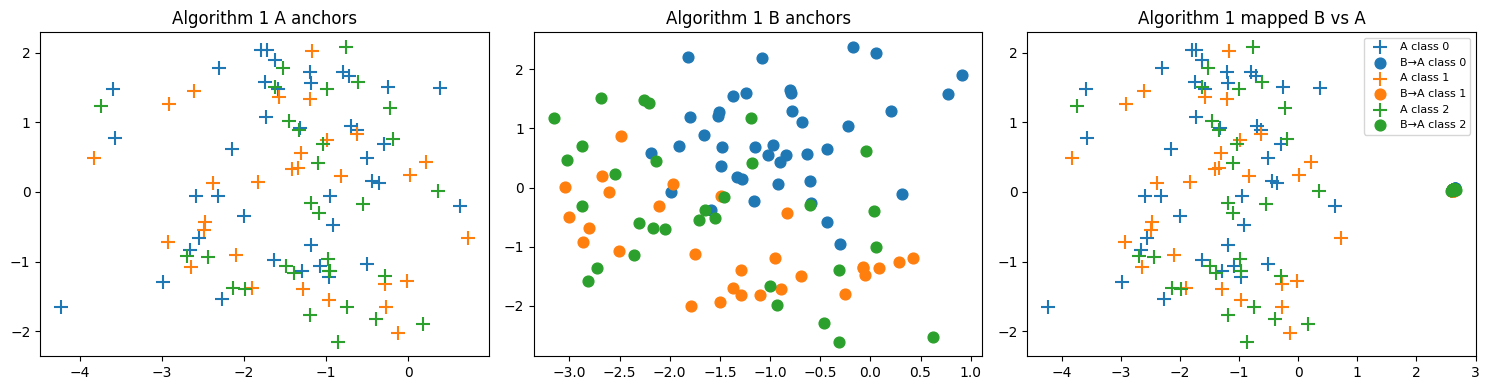

In [7]:
zB_anchor_mapped = algo1_result["zB_anchor_mapped"]

plot_alignment_pca(
    zA=zA_anchor,
    zB=zB_anchor,
    zB_mapped=zB_anchor_mapped,
    labels=y_anchor,
    title_prefix="Algorithm 1",
)

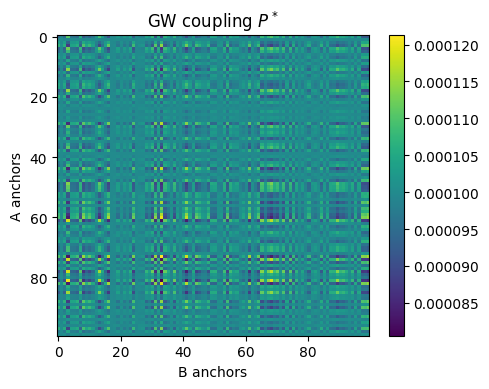

In [8]:
plt.figure(figsize=(5, 4))
plt.imshow(P_star, aspect="auto")
plt.colorbar()
plt.title("GW coupling $P^*$")
plt.xlabel("B anchors")
plt.ylabel("A anchors")
plt.tight_layout()
plt.show()

In [9]:
1/8

0.125

In [10]:
P_star

array([[9.44896371e-05, 9.90826446e-05, 9.50531607e-05, ...,
        9.23539795e-05, 9.22170502e-05, 9.14824385e-05],
       [9.99131670e-05, 1.00609215e-04, 9.94989384e-05, ...,
        9.97408444e-05, 1.00433030e-04, 9.94190845e-05],
       [1.03476962e-04, 1.00075298e-04, 1.03547097e-04, ...,
        1.04817701e-04, 1.04248901e-04, 1.05607468e-04],
       ...,
       [1.06146782e-04, 1.00859686e-04, 1.05538738e-04, ...,
        1.08650653e-04, 1.08761402e-04, 1.09675347e-04],
       [9.72100938e-05, 1.00078519e-04, 9.71393075e-05, ...,
        9.60264668e-05, 9.65299598e-05, 9.53227529e-05],
       [1.00811750e-04, 1.00067757e-04, 1.00866783e-04, ...,
        1.01059577e-04, 1.00893827e-04, 1.01191041e-04]], shape=(100, 100))